# Değişkenler Arası İlişkiler

## Amaç:
  1. Sayısal değişkenler arasındaki ilişkiyi korelasyon analizi ile incele
  2. Heatmap ile görselleştirme

## Adımlar:
  1. Veri setini yükle
  2. Sayısal sütunları belirle
  3. Korelasyon matrisini oluştur
  4. Heatmap ile görselleştirme

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Veriyi yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [8]:
# sayısal sütunları belirle
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [11]:
# Korelasyon matrisi
korelasyon_matrisi = df[sayisal_sutunlar].corr()
korelasyon_matrisi

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ay,siparis_gunu
adet,1.000000,-0.172545,-0.002466,0.032133,-0.013187,-0.001518,0.008099,0.425261,0.014705,0.084759,-0.001103
birim_fiyat,-0.172545,1.000000,-0.001571,0.009513,-0.021566,-0.001885,-0.029501,0.718637,-0.006057,-0.048085,-0.016287
indirim_orani,-0.002466,-0.001571,1.000000,0.009259,0.060925,-0.003986,-0.005531,-0.048178,0.030659,0.029693,0.002346
kargo_ucreti,0.032133,0.009513,0.009259,1.000000,0.000667,0.001636,0.007755,0.037641,0.084407,-0.036316,0.007812
teslimat_gunu,-0.013187,-0.021566,0.060925,0.000667,1.000000,-0.000634,0.034022,-0.018820,0.041525,0.007759,-0.001573
musteri_puani,-0.001518,-0.001885,-0.003986,0.001636,-0.000634,1.000000,0.014662,0.013423,-0.038700,-0.035946,-0.020190
kar_marji_orani,0.008099,-0.029501,-0.005531,0.007755,0.034022,0.014662,1.000000,-0.015829,-0.023314,0.015447,-0.019906
toplam_tutar,0.425261,0.718637,-0.048178,0.037641,-0.018820,0.013423,-0.015829,1.000000,0.004806,-0.000713,-0.024604
siparis_yili,0.014705,-0.006057,0.030659,0.084407,0.041525,-0.038700,-0.023314,0.004806,1.000000,0.048424,-0.043268
siparis_ay,0.084759,-0.048085,0.029693,-0.036316,0.007759,-0.035946,0.015447,-0.000713,0.048424,1.000000,-0.033585


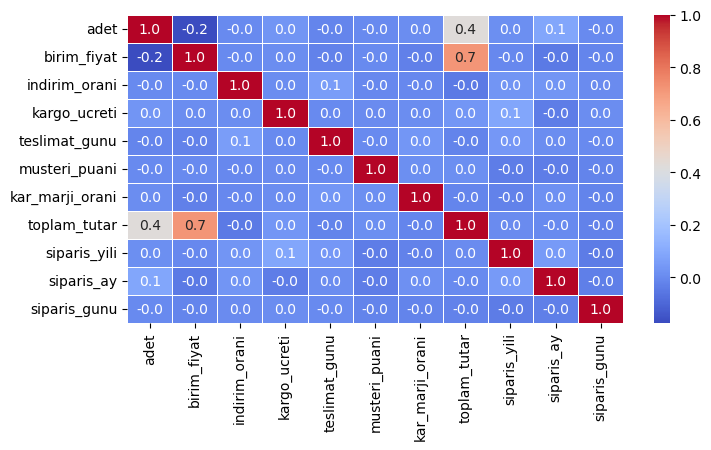

In [13]:
# Heatmap ile görselleştirme
plt.figure(figsize = (8,4))
sns.heatmap(korelasyon_matrisi, annot= True, fmt = ".1f", linewidth = 0.5, cmap = "coolwarm")
plt.show()

# Veri Hikayeleştirme ve İş Yorumu
Amaç:
  1. gerçek hayata benzeyen iş sorularını veri ile cevaplamak
  2. analiz sonuçlarını tablo, grafik ve kısa iş yorumları ile sunmaya çalışalım

Adımlar:
  1. Hangi kategori hem yüksek gelir üretiyor hem de müşteri memnuniyeti açısından güçlü görünüyor
  2. Hangi ödeme türleri daha yüksek ortalama sipariş tutarı üretiyor ve müşteri puanı açısından nasıl performans gösteriyor?
  3. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [20]:
# Hangi kategori hem yüksek gelir üretiyor hem de müşteri memnuniyeti açısından güçlü görünüyor
kategori_raporu = (
    df.groupby("kategori")
    .agg(
        toplam_gelir = ("toplam_tutar", "sum"),
        ortalama_musteri_puani = ("musteri_puani", "mean")
    )
)
kategori_raporu

,toplam_gelir,ortalama_musteri_puani
kategori,,
Elektronik,243084.26,3.974522
Ev Yaşam,151605.73,3.866337
Kitap,118439.83,3.991632
Kozmetik,160225.69,4.132075
Ofis,51252.50,3.935294
Spor,214372.56,3.961165


In [22]:
kategori_raporu = kategori_raporu.sort_values(by = ["toplam_gelir", "ortalama_musteri_puani"], ascending = [False, False])
kategori_raporu

,toplam_gelir,ortalama_musteri_puani
kategori,,
Elektronik,243084.26,3.974522
Spor,214372.56,3.961165
Kozmetik,160225.69,4.132075
Ev Yaşam,151605.73,3.866337
Kitap,118439.83,3.991632
Ofis,51252.50,3.935294


<Axes: xlabel='kategori', ylabel='toplam_gelir'>

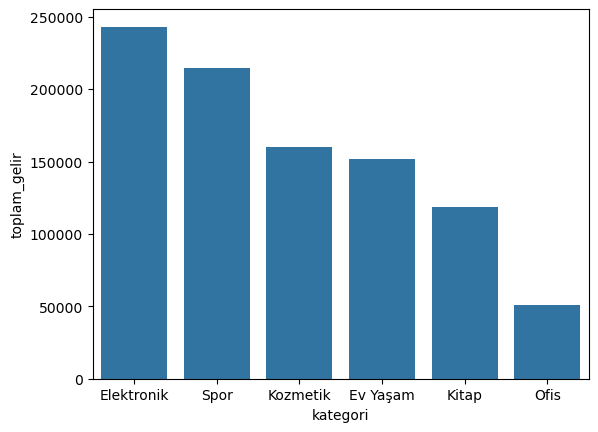

In [28]:
# Kategoriye göre toplam gelir
plt.figure()
sns.barplot(data = kategori_raporu.reset_index(), x = "kategori", y = "toplam_gelir")

<Axes: xlabel='kategori', ylabel='ortalama_musteri_puani'>

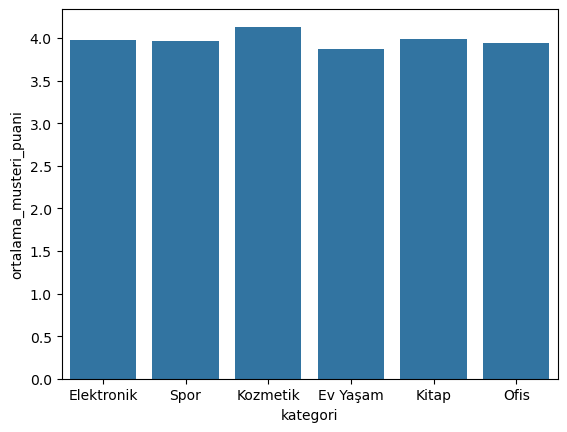

In [32]:
# Kategoriye göre ortalama müşteri puanı
plt.figure()
sns.barplot(data = kategori_raporu.reset_index(), x = "kategori", y = "ortalama_musteri_puani")